# 02. Engenharia de Features

**TCC — Modelo de Expected Goals com Aprendizado de Máquina**

Autor: Paulo Gustavo Angelo de Barros

Exploração das features geométricas, técnicas e contextuais geradas em `src/features.py`, comparando as três competições (Copa 2018, Copa 2022, Euro 2020).

## 1. Importações

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

from src.features import (
    RAW_DIR,
    COMPETICOES,
    extrair_features_geometricas,
    criar_variavel_alvo,
)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Carregando os dados (sem one-hot, para manter as categorias legíveis)

Para exploração, aplicamos apenas as transformações geométricas e a variável alvo — sem o one-hot encoding de `preparar_categoricas` — assim as colunas categóricas ficam legíveis nos agrupamentos abaixo.

In [2]:
def carregar_para_exploracao(nome: str) -> pd.DataFrame:
    """Carrega uma competição, remove pênaltis e aplica features geométricas + alvo."""
    df = pd.read_parquet(RAW_DIR / f"{nome}_shots.parquet")
    df = df[df["shot_type"] != "Penalty"].copy()
    df["under_pressure"] = df["under_pressure"].fillna(False).astype(int)
    df = extrair_features_geometricas(df)
    df = criar_variavel_alvo(df)
    return df


dfs = {nome: carregar_para_exploracao(nome) for nome in COMPETICOES}
df_all = pd.concat(dfs.values(), ignore_index=True)

print(f"Total de finalizações (sem pênaltis): {len(df_all)}")
df_all["competition"].value_counts()

Total de finalizações (sem pênaltis): 4302


competition
world_cup_2018    1638
world_cup_2022    1430
euro_2020         1234
Name: count, dtype: int64

## 3. Estatísticas descritivas de distância e ângulo

In [3]:
for nome, df in dfs.items():
    print(f"=== {nome} ===")
    print(df[["distancia_gol", "angulo_gol"]].describe().round(2))
    print()

=== world_cup_2018 ===
       distancia_gol  angulo_gol
count        1638.00     1638.00
mean           19.33       25.26
std             8.80       17.05
min             1.41        2.42
25%            12.04       14.47
50%            18.87       18.96
75%            25.96       30.93
max            61.52      150.26

=== world_cup_2022 ===
       distancia_gol  angulo_gol
count        1430.00     1430.00
mean           18.46       25.96
std             8.21       16.20
min             1.32        0.00
25%            11.91       15.45
50%            17.81       20.14
75%            24.48       31.60
max            70.83      143.92

=== euro_2020 ===
       distancia_gol  angulo_gol
count        1234.00     1234.00
mean           18.29       26.58
std             7.98       17.19
min             0.76        2.65
25%            11.77       15.81
50%            18.21       20.53
75%            24.32       31.95
max            58.48      160.04



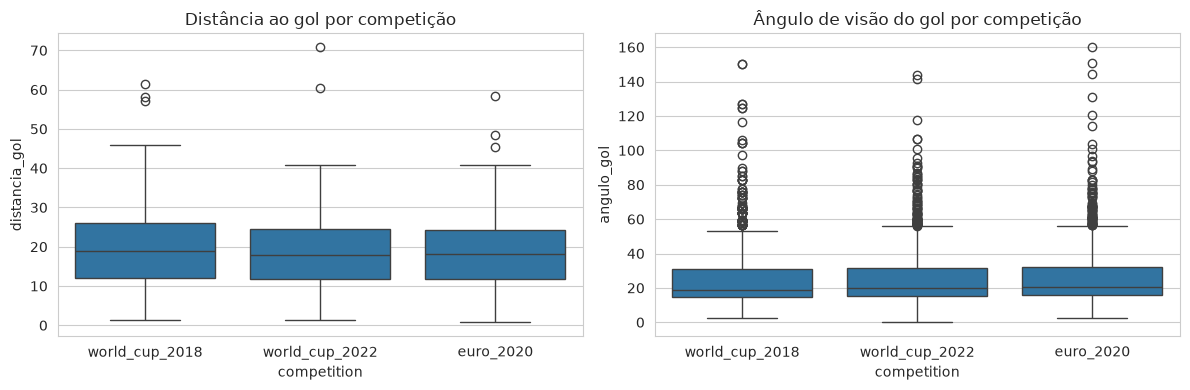

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_all, x="competition", y="distancia_gol", ax=axes[0])
axes[0].set_title("Distância ao gol por competição")
sns.boxplot(data=df_all, x="competition", y="angulo_gol", ax=axes[1])
axes[1].set_title("Ângulo de visão do gol por competição")
plt.tight_layout()
plt.show()

## 4. Taxa de conversão em gol por parte do corpo e situação de jogo

In [5]:
taxa_por_parte_corpo = (
    df_all.groupby("shot_body_part")["gol"]
    .agg(taxa_conversao="mean", n_chutes="count")
    .sort_values("taxa_conversao", ascending=False)
)
taxa_por_parte_corpo["taxa_conversao"] = (taxa_por_parte_corpo["taxa_conversao"] * 100).round(2)
taxa_por_parte_corpo

,taxa_conversao,n_chutes
shot_body_part,,
Other,12.90,31
Head,11.11,783
Left Foot,10.16,1299
Right Foot,8.50,2189


In [6]:
taxa_por_situacao = (
    df_all.groupby("play_pattern")["gol"]
    .agg(taxa_conversao="mean", n_chutes="count")
    .sort_values("taxa_conversao", ascending=False)
)
taxa_por_situacao["taxa_conversao"] = (taxa_por_situacao["taxa_conversao"] * 100).round(2)
taxa_por_situacao

,taxa_conversao,n_chutes
play_pattern,,
From Keeper,16.92,65
Other,16.67,12
From Counter,16.28,172
From Goal Kick,9.83,173
Regular Play,9.79,1511
From Throw In,9.04,785
From Free Kick,8.82,828
From Kick Off,8.70,46
From Corner,7.75,710


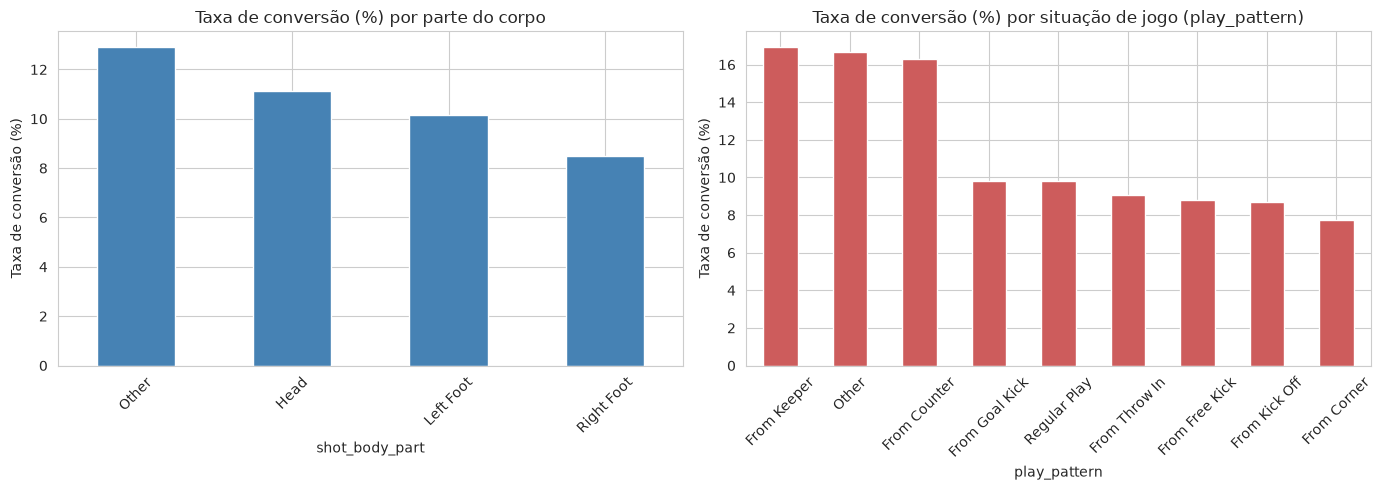

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

taxa_por_parte_corpo["taxa_conversao"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Taxa de conversão (%) por parte do corpo")
axes[0].set_ylabel("Taxa de conversão (%)")
axes[0].tick_params(axis="x", rotation=45)

taxa_por_situacao["taxa_conversao"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Taxa de conversão (%) por situação de jogo (play_pattern)")
axes[1].set_ylabel("Taxa de conversão (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Mapa de calor dos chutes no campo (mplsoccer)

Coordenadas já estão no sistema StatsBomb (pitch 120x80), então usamos `Pitch(pitch_type="statsbomb")` diretamente com as colunas `x`/`y`.

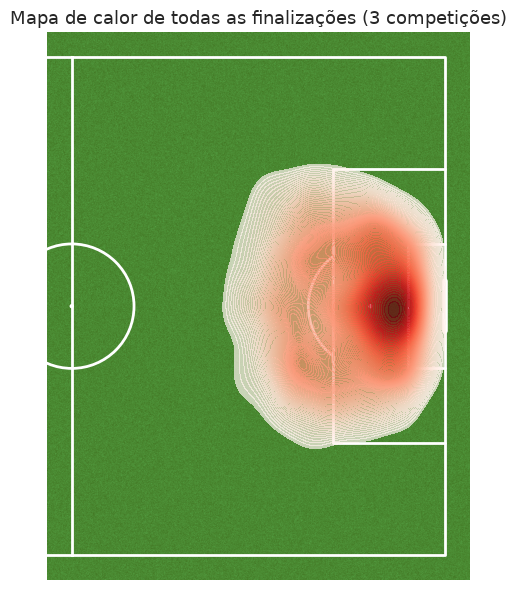

In [8]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white", half=True)
fig, ax = pitch.draw(figsize=(8, 6))
pitch.kdeplot(
    df_all["x"], df_all["y"], ax=ax,
    fill=True, cmap="Reds", levels=100, alpha=0.7,
)
ax.set_title("Mapa de calor de todas as finalizações (3 competições)", fontsize=13)
plt.show()

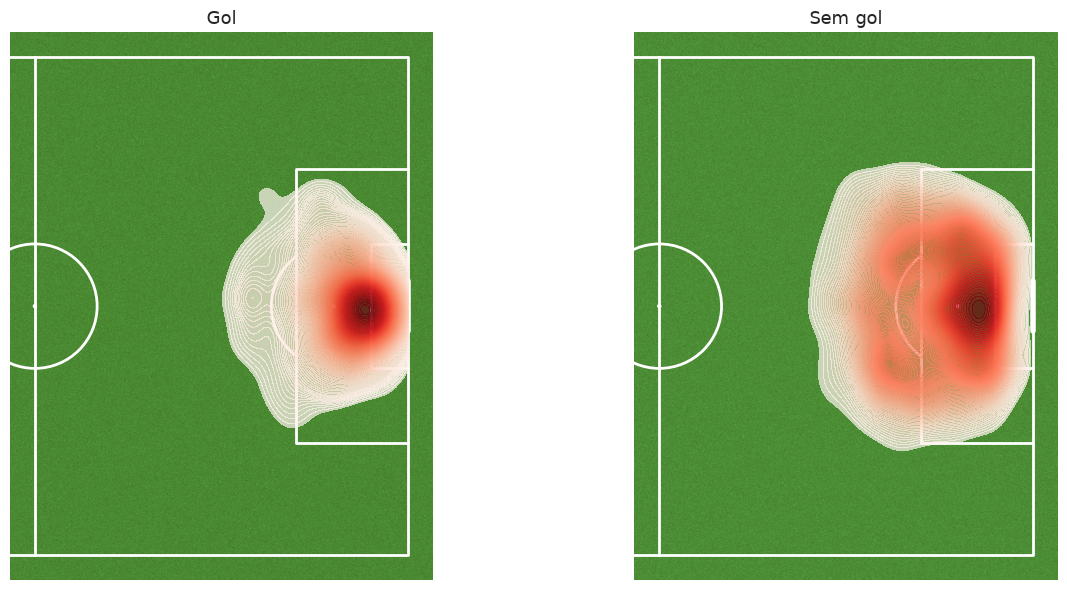

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pitch_dupla = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white", half=True)

for ax, (rotulo, subset) in zip(
    axes, [("Gol", df_all[df_all["gol"] == 1]), ("Sem gol", df_all[df_all["gol"] == 0])]
):
    pitch_dupla.draw(ax=ax)
    pitch_dupla.kdeplot(subset["x"], subset["y"], ax=ax, fill=True, cmap="Reds", levels=100, alpha=0.7)
    ax.set_title(rotulo, fontsize=13)

plt.tight_layout()
plt.show()

## 6. Comparação da distribuição de features entre as três competições

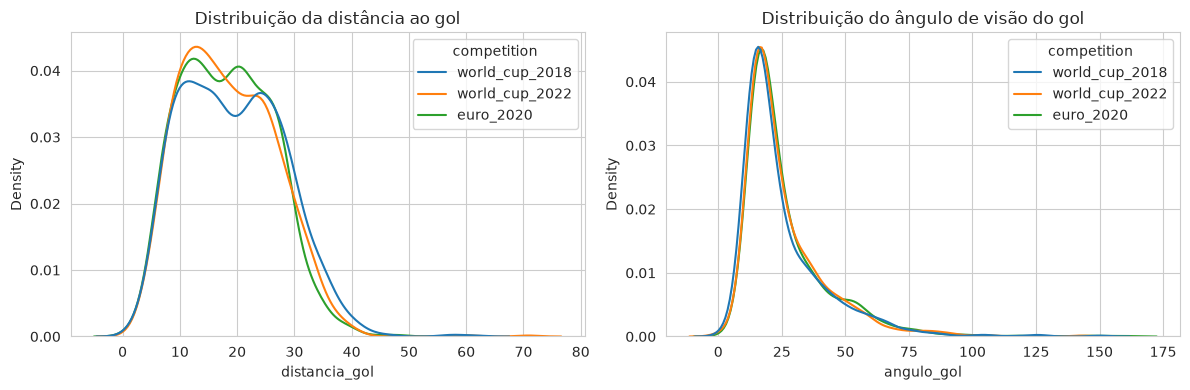

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=df_all, x="distancia_gol", hue="competition", ax=axes[0], common_norm=False)
axes[0].set_title("Distribuição da distância ao gol")

sns.kdeplot(data=df_all, x="angulo_gol", hue="competition", ax=axes[1], common_norm=False)
axes[1].set_title("Distribuição do ângulo de visão do gol")

plt.tight_layout()
plt.show()

In [11]:
comparacao = df_all.groupby("competition").agg(
    n_chutes=("gol", "count"),
    taxa_conversao=("gol", "mean"),
    distancia_media=("distancia_gol", "mean"),
    angulo_medio=("angulo_gol", "mean"),
    pct_sob_pressao=("under_pressure", "mean"),
)
comparacao["taxa_conversao"] = (comparacao["taxa_conversao"] * 100).round(2)
comparacao["pct_sob_pressao"] = (comparacao["pct_sob_pressao"] * 100).round(2)
comparacao.round(2)

,n_chutes,taxa_conversao,distancia_media,angulo_medio,pct_sob_pressao
competition,,,,,
euro_2020,1234,9.89,18.29,26.58,24.72
world_cup_2018,1638,8.24,19.33,25.26,20.09
world_cup_2022,1430,10.63,18.46,25.96,16.64


## 7. Próximos passos

Com as features validadas, o pipeline completo (incluindo one-hot encoding) já está disponível em `src/features.py::processar_competicao`, gerando os arquivos em `data/processed/`. 

No próximo notebook (`03_modelos.ipynb`) treinaremos e compararemos os três modelos: Regressão Logística, Random Forest e XGBoost.